# NeSPReSO Cookbook

An interactive, runnable companion to the questions raised about the
[`v2-nespreso`](https://github.com/0jrm/v2-nespreso) repository.

NeSPReSO predicts subsurface temperature/salinity profiles from satellite surface
fields (SST, SSS, SSH) + position/time, using an MLP that regresses **PCA components**
of the profiles. This notebook walks through the same points covered in José's email,
but as cells you can read, adapt, and run.

## What this notebook covers

1. **Is there an interactive runnable, or is everything from the terminal?**
   The package is CLI-first, but every step is a plain Python function you can call
   from here. We show both.
2. **When downloading data, can specific months/dates be selected?**
   Yes — date range + bounding box, fully from the CLI. We also show how to target
   specific dates/months for *inference*.
3. **Is there automatic hyperparameter tuning, or trial-and-error?**
   No auto-tuner is wired in. We show the knobs, early stopping, TensorBoard
   monitoring, and how to script an `n_components` sweep.
4. **Can we tell a local vs. global minimum?**
   Not strictly. We show the practical mitigation: multiple seeds (`n_runs`) and
   ensembling.
5. **Applying NeSPReSO to a new region / different inputs or outputs.**
   Region change is config-only; we show the `NEW_BASIN` checklist and the
   structural limits for changing inputs/outputs.

> **Environment note.** The full pipeline expects real data under `/unity/...` and a
> GPU (an HPC environment). Cells that need that data are clearly marked and guarded
> so this notebook still *opens and runs* on a laptop — they no-op with an explanation
> instead of crashing.

## 0. Setup

Install the package in editable mode from the repo root (one-time):

```bash
cd v2-nespreso
pip install -e ".[dev]"
# optional extras for downloading + live monitoring:
pip install -e ".[download,monitor]"
```

The cell below makes `nespreso` importable from this notebook (whether or not it was
`pip install`-ed) and loads the default config so the rest of the notebook has a
`cfg` object to inspect and override.

In [24]:
import sys
from pathlib import Path

# Locate the repo root (this notebook lives in <repo>/notebooks/).
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from dataclasses import asdict, replace

from nespreso.config import load_config

# load_config() with no argument reads configs/default.yaml from the repo root.
cfg = load_config(REPO_ROOT / "configs" / "default.yaml")

print("Bounding box :", asdict(cfg.bbox))
print("Model knobs  :", asdict(cfg.model))
print("Input params :", asdict(cfg.input_params))
print("Runtime flags:", asdict(cfg.runtime))

Bounding box : {'min_lat': 18.0, 'max_lat': 31.0, 'min_lon': -98.0, 'max_lon': -81.0, 'ex_lat': 23.0, 'ex_lon': -90.0}
Model knobs  : {'n_components': 15, 'layers_config': (512, 512), 'batch_size': 512, 'min_depth': 0, 'max_depth': 1800, 'dropout_prob': 0.2, 'epochs': 8000, 'patience': 500, 'learning_rate': 0.001, 'train_size': 0.7, 'val_size': 0.15, 'test_size': 0.15}
Input params : {'timecos': True, 'timesin': True, 'latcos': True, 'latsin': True, 'loncos': True, 'lonsin': True, 'sat': True, 'sst': True, 'sss': True, 'ssh': True}
Runtime flags: {'load_trained_model': False, 'ensemble_models': False, 'load_dataset_file': True, 'gen_paula_profiles': False, 'debug': False, 'seed': 42, 'n_runs': 1, 'nn_repeat_time': 10, 'gem_repeat_time': 1}


## 1. Is there an interactive runnable, or is everything from the terminal?

There is **no GUI**. NeSPReSO is CLI-first, with two subcommands defined in
[`src/nespreso/cli.py`](../src/nespreso/cli.py): `train` and `download`.

The main training entry point is:

```bash
python -m nespreso --config configs/default.yaml train --tensorboard --log-dir runs/gom
```

- `--config` points at a YAML (defaults to `configs/default.yaml`).
- `--tensorboard` (optional) turns on live loss logging during training.
- `--log-dir` (optional) sets where TensorBoard writes.

The training workflow (`run_training` in [`src/nespreso/runner.py`](../src/nespreso/runner.py)):
build/load the dataset pickle → 0.7/0.15/0.15 split → fit GEM on the validation
subset → train with early stopping → save one checkpoint under `paths.saved_models_dir`.

The legacy monolith `singleFileModel_SAT...py` still runs the full analysis + plotting
pipeline directly (`python singleFileModel_SAT_stats4verticalProj_meeting20260203.py`).

### "Interactive" from Python

Even though there's no GUI, every CLI step is just a function call. From a notebook you
can load a config, override knobs in memory, and call `run_training(cfg)` yourself —
that *is* the interactive runnable. The cell below shows the wiring (it does **not**
train, since that needs `/unity` data + GPU).

In [25]:
from nespreso.runner import run_training

# Does the configured ARGO file exist on this machine? (It lives on /unity in production.)
argo_available = Path(cfg.paths.argo_mat).exists()

if argo_available:
    # This is the programmatic equivalent of `python -m nespreso ... train`.
    # Uncomment to actually train (long-running, needs GPU):
    # checkpoint_path = run_training(cfg)
    # print("Saved checkpoint:", checkpoint_path)
    print("Data found. Call run_training(cfg) to train (kept commented to avoid a long run).")
else:
    print("Skipping training: ARGO data not found at")
    print("  ", cfg.paths.argo_mat)
    print("Run this on the HPC node where /unity is mounted, or point paths.* at local data.")
    print("\nThe equivalent CLI command would be:")
    print("  python -m nespreso --config configs/default.yaml train --tensorboard --log-dir runs/gom")

Data found. Call run_training(cfg) to train (kept commented to avoid a long run).


## 2. Downloading data — can specific months/dates be selected?

**Yes.** Satellite downloads are fully defined by a **date range + bounding box**, no
manual file editing required (as long as the observation files exist and are named as
the downloaders expect). The `download` subcommand lives in
[`src/nespreso/cli.py`](../src/nespreso/cli.py):

```bash
# OSTIA SST (via copernicusmarine) — date range + bbox
python -m nespreso download ostia --output /path/SST \
    --start 2014-01-01 --end 2014-06-30 \
    --min-lon -99 --max-lon -74 --min-lat 17 --max-lat 31

# SSS (copernicusmarine day loop) — date range + bbox
python -m nespreso download sss --output /path/SSS \
    --start 2014-01-01 --end 2014-06-30 \
    --min-lon -99 --max-lon -74 --min-lat 17 --max-lat 31

# AVISO SSH — year loop + bbox (note: --start-year/--end-year, not --start/--end)
python -m nespreso download aviso --output /path/AVISO \
    --start-year 2014 --end-year 2014 \
    --min-lon 262 --max-lon 305 --min-lat 7.5 --max-lat 50
```

Then point your config at those folders:

```yaml
paths:
  sst_folder:   /path/SST
  sss_folder:   /path/SSS
  aviso_folder: /path/AVISO
```

The readers in
[`src/nespreso/io/satellite_readers.py`](../src/nespreso/io/satellite_readers.py)
expect the naming conventions these downloaders produce (or the legacy GoM layout).

> **To download only specific months**, just pick the `--start`/`--end` (or
> `--start-year`/`--end-year`) that bracket them. There's no separate "month picker";
> the date range *is* the selector. Credentials: CMEMS via `~/.netrc` or
> `copernicusmarine login`; AVISO motuclient uses the `AVISO` host in `~/.netrc`.

### 2b. Targeting specific dates/months for *inference*

For **inference**, dates and locations are **not** chosen through the download CLI —
you pass them explicitly as arrays. There is no inference subcommand yet; you build the
inputs in code and run the trained model. The recipe (per José):

1. Define arrays for the profiles you want: `time`, `lat`, `lon`.
2. Interpolate satellite values for those dates/locations — e.g.
   `load_satellite_data()` in [`src/nespreso/io/satellite.py`](../src/nespreso/io/satellite.py),
   or precomputed arrays (as the glider experiment does).
3. Build the feature tensor with `prepare_inputs()` in
   [`src/nespreso/data/features.py`](../src/nespreso/data/features.py).
4. Run the model and invert PCA with `predict_with_numpy()`
   ([`inference.py`](../src/nespreso/inference.py)) and `inverse_transform()`
   ([`data/dataset.py`](../src/nespreso/data/dataset.py)).

So for inference you **can** target any specific dates/months — the only constraint is
that satellite files must already exist for those dates (from a download range covering
them). The glider experiment
([`experiments/glider_mission.py`](../src/nespreso/experiments/glider_mission.py)) is
the canonical worked example.

The next cells implement this recipe step by step.

In [26]:
# --- Inference step 1: define the dates/locations you want profiles for ---
# Pick *any* dates/months here. This is how you "select specific months" for inference.
import numpy as np
from datetime import datetime

from nespreso.utils.time import datenum_to_datetime  # used by readers/experiments

# prepare_inputs() expects `time` as MATLAB datenums (seasonal harmonics use time % 365),
# while load_satellite_data() expects Python datetimes. We build both from the same dates.
def datetime_to_datenum(dt: datetime) -> float:
    """Inverse of nespreso.utils.time.datenum_to_datetime (note the +366 MATLAB offset)."""
    frac = (dt.hour * 3600 + dt.minute * 60 + dt.second) / 86400.0
    return dt.toordinal() + 366 + frac

# Example: three target dates spanning seasons, at a few Gulf-of-Mexico points.
# SMAP SSS files in the default config folder start around 2015; earlier dates leave NaNs.
target_datetimes = [
    datetime(2015, 6, 15),
    datetime(2015, 9, 15),
    datetime(2015, 11, 15),
]
lat = np.array([25.0, 24.0, 26.0])
lon = np.array([-90.0, -88.0, -92.0])
time_datenum = np.array([datetime_to_datenum(d) for d in target_datetimes])

print("Target datetimes:", [d.date().isoformat() for d in target_datetimes])
print("As MATLAB datenums:", time_datenum)
print("lat:", lat, "lon:", lon)

Target datetimes: ['2015-06-15', '2015-09-15', '2015-11-15']
As MATLAB datenums: [736130. 736222. 736283.]
lat: [25. 24. 26.] lon: [-90. -88. -92.]


In [27]:
# --- Inference step 2: interpolate satellite fields at those dates/locations ---
# load_satellite_data_for_dataset(...) reads SSS/SST/SSH from config paths + bbox.
from nespreso.io.satellite import load_satellite_data_for_dataset

# Placeholders let the rest of the recipe run when files are missing.
# NOTE: prepare_inputs() subtracts 273.15 from SST, so SST must be in KELVIN here.
_PLACEHOLDER_SSS = np.array([36.2, 36.0, 36.4])   # PSU
_PLACEHOLDER_SST = np.array([295.0, 303.0, 299.0])  # Kelvin
_PLACEHOLDER_SSH = np.array([0.10, 0.25, -0.05])   # m (anomaly)

sat_folders_exist = all(
    Path(p).exists()
    for p in (cfg.paths.sss_folder, cfg.paths.sst_folder, cfg.paths.aviso_folder)
)

if sat_folders_exist:
    sss, sst, ssh = load_satellite_data_for_dataset(
        target_datetimes, lat, lon,
        cfg.paths.aviso_folder, cfg.paths.sst_folder, cfg.paths.sss_folder,
        cfg.bbox.min_lat, cfg.bbox.max_lat, cfg.bbox.min_lon, cfg.bbox.max_lon,
        cfg.bbox.ex_lat, cfg.bbox.ex_lon,
    )
    sss = np.asarray(sss, dtype=float)
    sst = np.asarray(sst, dtype=float)
    ssh = np.asarray(ssh, dtype=float)
    if np.isnan(sss).any():
        print(f"SSS missing for {int(np.isnan(sss).sum())} point(s); filling with placeholders.")
        sss = np.where(np.isnan(sss), _PLACEHOLDER_SSS, sss)
    if np.isnan(sst).any():
        print(f"SST missing for {int(np.isnan(sst).sum())} point(s); filling with placeholders.")
        sst = np.where(np.isnan(sst), _PLACEHOLDER_SST, sst)
    if np.isnan(ssh).any():
        print(f"SSH missing for {int(np.isnan(ssh).sum())} point(s); filling with placeholders.")
        ssh = np.where(np.isnan(ssh), _PLACEHOLDER_SSH, ssh)
    print("Interpolated -> sss:", sss, "sst(K):", sst, "ssh:", ssh)
else:
    print("Satellite folders not found on this machine; using placeholder surface values")
    print("so the rest of the recipe still runs. Replace these with real interpolated data.")
    sss, sst, ssh = _PLACEHOLDER_SSS, _PLACEHOLDER_SST, _PLACEHOLDER_SSH

Loading Satellite Data: 100%|██████████| 3/3 [00:00<00:00, 10.69it/s]

Interpolated -> sss: [37.01610756 36.31940079 36.71188545] sst(K): [301.486 302.859 298.93 ] ssh: [-0.10416749 -0.08984954 -0.32550616]


In [28]:
# --- Inference step 3: build the feature tensor ---
# prepare_inputs() turns (time, lat, lon, sss, sst, ssh) into the model input tensor,
# honoring the input_params flags (seasonal harmonics + which satellite fields to use).
from nespreso.data.features import prepare_inputs

input_params = asdict(cfg.input_params)
features = prepare_inputs(time_datenum, lat, lon, sss, sst, ssh, input_params)

print("Feature tensor shape:", tuple(features.shape), "(n_samples, input_dim)")
print(features)

# Sanity check: input_dim derived from the flags (matches runner.py).
input_dim = sum(v for v in input_params.values()) - 1 * input_params["sat"]
print("Expected input_dim from input_params:", input_dim)

Feature tensor shape: (3, 9) (n_samples, input_dim)
tensor([[ 2.7610e-01, -9.6113e-01,  6.4279e-01,  7.6604e-01,  6.1232e-17,
         -1.0000e+00,  3.7016e+01,  2.8336e+01, -1.0417e-01],
        [ 9.5749e-01,  2.8848e-01,  6.6913e-01,  7.4314e-01,  3.4899e-02,
         -9.9939e-01,  3.6319e+01,  2.9709e+01, -8.9850e-02],
        [ 2.2612e-01,  9.7410e-01,  6.1566e-01,  7.8801e-01, -3.4899e-02,
         -9.9939e-01,  3.6712e+01,  2.5780e+01, -3.2551e-01]])
Expected input_dim from input_params: 9


In [29]:
# --- Inference step 4: run the model and invert PCA back to profiles ---
# A trained checkpoint stores both the network weights AND the fitted PCA objects:
#   {"model_state_dict": ..., "pca_temp": ..., "pca_sal": ..., "input_params": ...}
import glob
import torch

from nespreso.determinism import get_device
from nespreso.inference import predict_with_numpy
from nespreso.models.mlp import PredictionModel
from nespreso.data.pca import sklearn_inverse_transform_pcs

# Resolve a checkpoint: explicit config path, else newest in saved_models_dir.
ckpt_path = None
if cfg.paths.trained_model_path and Path(cfg.paths.trained_model_path).exists():
    ckpt_path = cfg.paths.trained_model_path
else:
    candidates = sorted(glob.glob(str(Path(cfg.paths.saved_models_dir) / "*.pth")))
    ckpt_path = candidates[-1] if candidates else None

if ckpt_path:
    device = get_device()
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

    model = PredictionModel(
        input_dim=input_dim,
        layers_config=list(cfg.model.layers_config),
        output_dim=cfg.model.n_components * 2,   # n_components T + n_components S
        dropout_prob=cfg.model.dropout_prob,
    )
    model.load_state_dict(ckpt["model_state_dict"])
    model.to(device).eval()

    # NOTE: predict_with_numpy() decides GPU placement via `if device == "cuda"`,
    # comparing against the *string* "cuda". get_device() returns a torch.device
    # object, which is NOT == "cuda", so the input tensor would be left on the CPU
    # while the model sits on the GPU -> "tensors on different devices" RuntimeError.
    # Pass the string form so the helper moves both consistently.
    device_str = "cuda" if torch.cuda.is_available() else "cpu"
    pcs = predict_with_numpy(model, features.numpy(), device=device_str)   # (n_samples, 2*n_components)
    temp_profiles, sal_profiles = sklearn_inverse_transform_pcs(
        pcs, ckpt["pca_temp"], ckpt["pca_sal"], cfg.model.n_components
    )
    print("Predicted PCA coeffs shape:", pcs.shape)
    print("Temperature profiles shape:", temp_profiles.shape, "(depth, n_samples)")
    print("Salinity   profiles shape:", sal_profiles.shape)
else:
    print("No trained checkpoint found under", cfg.paths.saved_models_dir)
    print("Train one first (Section 1) or set paths.trained_model_path, then re-run this cell.")
    print("\nWith a checkpoint, this cell would produce full-depth T/S profiles for each")
    print("of the target dates/locations defined above.")

Predicted PCA coeffs shape: (3, 30)
Temperature profiles shape: (1801, 3) (depth, n_samples)
Salinity   profiles shape: (1801, 3)


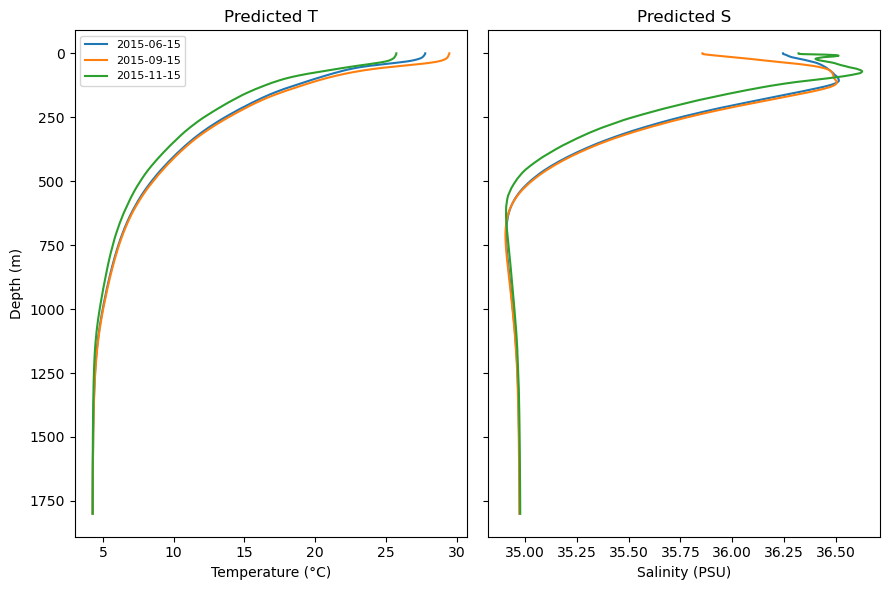

In [30]:
# --- Optional: plot the predicted profiles (only if step 4 produced them) ---
if "temp_profiles" in globals():
    import matplotlib.pyplot as plt

    depth = np.arange(temp_profiles.shape[0])  # model depth grid (index = meters here)
    fig, (axT, axS) = plt.subplots(1, 2, figsize=(9, 6), sharey=True)
    for i, d in enumerate(target_datetimes):
        axT.plot(temp_profiles[:, i], depth, label=d.date().isoformat())
        axS.plot(sal_profiles[:, i], depth, label=d.date().isoformat())
    axT.set(xlabel="Temperature (°C)", ylabel="Depth (m)", title="Predicted T")
    axS.set(xlabel="Salinity (PSU)", title="Predicted S")
    axT.invert_yaxis()
    axT.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("No profiles to plot yet (no trained checkpoint). See Section 1 to train.")

### A note on *training* data vs. inference dates

For **training** (ARGO profiles, not inference), the time span is determined by the
profiles in your regional ARGO `.mat` (`paths.argo_mat`) — **not** by a date filter in
the config. To train on specific months only, subset the ARGO file beforehand (or add a
filter in code). The `bbox` limits the spatial domain; your satellite folders must cover
the date range of the profiles you keep.

## 3. Hyperparameters — automatic tuning or trial-and-error?

There is **no built-in hyperparameter optimizer** (no grid search, no Bayesian
optimization). Tuning is manual. The knobs live in `configs/default.yaml` under `model`:

| Parameter | Default | Notes |
|-----------|---------|-------|
| `n_components` | 15 | PCA complexity. Sweep ~10–20 for a new region. |
| `layers_config` | [512, 512] | MLP width/depth. |
| `learning_rate` | 0.001 | Watch train/val curves; lower it later if learning is healthy. |
| `batch_size` | 512 | ~1024 is reasonable with enough profiles + GPU memory. |
| `epochs` | 8000 | Upper bound; rarely reached. |
| `patience` | 500 | **Early stopping** horizon — this is what really controls run length. |
| `dropout_prob` | 0.2 | |

Practical guidance (from `docs/HOWTO.md` and Olmo's note):

- **Epochs** are effectively governed by **early stopping** (`patience` epochs with no
  validation improvement → stop), in `train_model()` in
  [`src/nespreso/train.py`](../src/nespreso/train.py).
- **`batch_size`**: ~1024 if you have enough profiles and GPU memory.
- **`learning_rate`**: monitor train/val curves (TensorBoard). If it's learning at a
  good pace, keep it, then decrease later.
- For a new region, sweep mainly `n_components` (10–20) and experiment with `patience`.

In [31]:
# Overriding hyperparameters in memory (no YAML editing needed).
# AppConfig is a frozen dataclass; use dataclasses.replace to make modified copies.
cfg_fast = replace(
    cfg,
    model=replace(cfg.model, n_components=12, batch_size=1024, learning_rate=5e-4, epochs=200, patience=20),
)
print("Original :", asdict(cfg.model))
print("Overridden:", asdict(cfg_fast.model))

# You'd then call run_training(cfg_fast) just like the CLI does.
# (Equivalent to editing configs/default.yaml and passing --config.)

Original : {'n_components': 15, 'layers_config': (512, 512), 'batch_size': 512, 'min_depth': 0, 'max_depth': 1800, 'dropout_prob': 0.2, 'epochs': 8000, 'patience': 500, 'learning_rate': 0.001, 'train_size': 0.7, 'val_size': 0.15, 'test_size': 0.15}
Overridden: {'n_components': 12, 'layers_config': (512, 512), 'batch_size': 1024, 'min_depth': 0, 'max_depth': 1800, 'dropout_prob': 0.2, 'epochs': 200, 'patience': 20, 'learning_rate': 0.0005, 'train_size': 0.7, 'val_size': 0.15, 'test_size': 0.15}


### Live monitoring with TensorBoard

Turn on logging with `--tensorboard` (or `monitor.tensorboard: true` in YAML). Default is
**off** so numerics match the legacy monolith. `train_model()` logs `loss/train` and
`loss/val` per epoch.

```bash
python -m nespreso --config configs/default.yaml train --tensorboard --log-dir runs/gom
tensorboard --logdir runs/gom
```

Use the curves to decide on `learning_rate` and to confirm early stopping is kicking in
at a sensible epoch.

### Scripting an `n_components` sweep

There's no auto-tuner, but you can script a sweep around the existing pipeline. The
pattern below builds a modified config per value and trains; compare the validation
RMSE / test loss that `run_training` reports (or evaluate yourself via
`evaluate_model`).

In [32]:
# A minimal n_components sweep scaffold. Each run refits PCA + retrains, so this is slow;
# keep epochs modest while exploring, then do a full run on the winner.
from nespreso.runner import run_training
from nespreso.train import evaluate_model


def sweep_n_components(base_cfg, values=(10, 12, 15, 18, 20), epochs=200, patience=20):
    results = {}
    for n in values:
        run_cfg = replace(
            base_cfg,
            model=replace(base_cfg.model, n_components=n, epochs=epochs, patience=patience),
        )
        # return_artifacts=True hands back the trained model + loaders for evaluation.
        save_path, art = run_training(run_cfg, return_artifacts=True)
        # Re-derive the loss used in training to score the validation split:
        from nespreso.config import density_penalty_dict
        from nespreso.losses import CombinedPCALoss
        criterion = CombinedPCALoss(
            temp_pca=art.train_dataset.dataset,
            sal_pca=art.train_dataset.dataset,
            n_components=n,
            weights=art.full_dataset.get_pca_weights(),
            device=art.device,
            density_config=density_penalty_dict(run_cfg),
        )
        val_loss = evaluate_model(art.trained_model, art.val_loader, criterion, art.device)
        results[n] = val_loss
        print(f"n_components={n:2d} -> val loss {val_loss:.4f}")
    best = min(results, key=results.get)
    print("Best n_components:", best)
    return results


if argo_available:
    print("Ready to sweep. Uncomment to run (slow, needs GPU):")
    print("# sweep_n_components(cfg)")
else:
    print("Sweep scaffold defined. Run it on the HPC node where ARGO + satellite data live.")

Ready to sweep. Uncomment to run (slow, needs GPU):
# sweep_n_components(cfg)


## 4. Local vs. global minimum — can we tell?

**Not in a strict sense.** We don't know the full shape of the optimization landscape.

The practical mitigation already in the code: run **multiple trainings with different
seeds** via `runtime.n_runs` (+ `runtime.seed`), and optionally **ensemble** the
resulting models via `runtime.ensemble_models`. Then compare validation RMSE across
runs — consistent, low RMSE across seeds is your evidence that you're in a good basin,
even if you can't prove it's global.

- Seeding is centralized in `set_seed()` (called by `run_training` via
  `apply_runtime_globals`), see [`src/nespreso/determinism.py`](../src/nespreso/determinism.py).
- `run_training` loops `for run in range(cfg.runtime.n_runs)` and saves one checkpoint
  per run under `paths.saved_models_dir`.

In [33]:
# Configure a multi-seed run + ensembling. run_training saves one checkpoint per run;
# load_all_models() in inference.py can then load the ensemble for averaging.
cfg_multi = replace(
    cfg,
    runtime=replace(cfg.runtime, n_runs=5, ensemble_models=True, seed=42),
)
print("n_runs:", cfg_multi.runtime.n_runs)
print("ensemble_models:", cfg_multi.runtime.ensemble_models)
print("seed:", cfg_multi.runtime.seed)

# After training cfg_multi, load the ensemble and average predictions:
from nespreso.inference import load_all_models  # noqa: F401
print(
    "\nWorkflow:\n"
    "  run_training(cfg_multi)                       # writes 5 checkpoints\n"
    "  models = load_all_models(cfg.paths.saved_models_dir, device, input_dim,\n"
    "                           list(cfg.model.layers_config), cfg.model.n_components,\n"
    "                           cfg.model.dropout_prob)\n"
    "  # average each model's predict_with_numpy(...) output, then inverse_transform.\n"
    "Compare per-run validation RMSE to gauge how seed-sensitive your minimum is."
)

n_runs: 5
ensemble_models: True
seed: 42

Workflow:
  run_training(cfg_multi)                       # writes 5 checkpoints
  models = load_all_models(cfg.paths.saved_models_dir, device, input_dim,
                           list(cfg.model.layers_config), cfg.model.n_components,
                           cfg.model.dropout_prob)
  # average each model's predict_with_numpy(...) output, then inverse_transform.
Compare per-run validation RMSE to gauge how seed-sensitive your minimum is.


## 5. Applying NeSPReSO to a new region (and changing inputs/outputs)

### Changing the region — config only

This is well supported and mostly configuration-based (see `docs/NEW_BASIN.md`):

1. Point `paths.argo_mat` at the regional ARGO `.mat` (same layout: `TIME`, `LAT`,
   `LON`, `TEMP`, `SAL`, `PRES`, `SH1950`).
2. Set the new `bbox` (and exclusion point `ex_lat`/`ex_lon`).
3. Point `paths.aviso_folder` / `sst_folder` / `sss_folder` at satellite data covering
   the region + period (download it with the CLI from Section 2).
4. Use a **fresh** `paths.dataset_pickle` so you don't overwrite GoM artifacts.

PCA and GEM are **refit automatically** on the new profiles through the dataset logic in
[`src/nespreso/data/dataset.py`](../src/nespreso/data/dataset.py) — `reload()`,
`_apply_pca`, and `calc_gem` (GEM is fit on the validation split).

### Toggling existing inputs — config only

SST / SSS / SSH and the seasonal/position harmonics are switched on/off via
`input_params` in the config. The input dimension is derived automatically in
[`src/nespreso/runner.py`](../src/nespreso/runner.py)
(`input_dim = sum(flags) - 1*sat`), so you don't hand-edit any layer sizes.

### Adding *new* input variable types (e.g. chlorophyll) — code changes

Requires edits in several places: `src/nespreso/data/features.py` (`prepare_inputs`),
the dataset `__getitem__`, the satellite readers, and the `input_dim` computation.

### Changing the *outputs* (predict something other than T/S) — structural

The model is hardwired around TEMP/SAL PCA outputs with `output_dim = n_components * 2`.
Changing outputs touches the dataset, the loss functions
([`src/nespreso/losses.py`](../src/nespreso/losses.py)), and the inverse transforms.
This is a larger change (José is porting this into a more flexible template).

In [34]:
# Build a "new basin" config in memory (e.g. Eastern Pacific). In practice you'd copy
# configs/default.yaml -> configs/my_basin.yaml and edit it, then pass --config.
cfg_pacific = replace(
    cfg,
    paths=replace(
        cfg.paths,
        argo_mat="/path/to/ARGO_EPac.mat",
        aviso_folder="/path/to/EPac/AVISO",
        sst_folder="/path/to/EPac/SST",
        sss_folder="/path/to/EPac/SSS",
        dataset_pickle="/path/to/EPac/config_dataset_full.pkl",  # fresh pickle!
    ),
    bbox=replace(cfg.bbox, min_lat=5.0, max_lat=30.0, min_lon=-120.0, max_lon=-95.0,
                 ex_lat=5.0, ex_lon=-120.0),
)
print("New-basin paths:", asdict(cfg_pacific.paths))
print("New-basin bbox :", asdict(cfg_pacific.bbox))

# Example of toggling an input off (drop SSS) — input_dim updates automatically.
cfg_no_sss = replace(cfg, input_params=replace(cfg.input_params, sss=False))
new_input_dim = sum(asdict(cfg_no_sss.input_params).values()) - 1 * cfg_no_sss.input_params.sat
print("\ninput_dim with SSS off:", new_input_dim, "(was", input_dim, ")")

New-basin paths: {'argo_mat': '/path/to/ARGO_EPac.mat', 'aviso_folder': '/path/to/EPac/AVISO', 'sst_folder': '/path/to/EPac/SST', 'sss_folder': '/path/to/EPac/SSS', 'dataset_pickle': '/path/to/EPac/config_dataset_full.pkl', 'saved_models_dir': '/unity/g2/jmiranda/SubsurfaceFields/GEM_SubsurfaceFields/saved_models', 'trained_model_path': None}
New-basin bbox : {'min_lat': 5.0, 'max_lat': 30.0, 'min_lon': -120.0, 'max_lon': -95.0, 'ex_lat': 5.0, 'ex_lon': -120.0}

input_dim with SSS off: 8 (was 9 )


## References (source of truth)

- CLI / entry points — [`src/nespreso/cli.py`](../src/nespreso/cli.py)
- Training pipeline — [`src/nespreso/runner.py`](../src/nespreso/runner.py),
  [`src/nespreso/train.py`](../src/nespreso/train.py)
- Config schema — [`src/nespreso/config.py`](../src/nespreso/config.py),
  [`configs/default.yaml`](../configs/default.yaml)
- Inference — [`src/nespreso/inference.py`](../src/nespreso/inference.py),
  [`src/nespreso/data/features.py`](../src/nespreso/data/features.py),
  [`src/nespreso/data/pca.py`](../src/nespreso/data/pca.py)
- Satellite I/O — [`src/nespreso/io/satellite.py`](../src/nespreso/io/satellite.py),
  [`src/nespreso/io/satellite_readers.py`](../src/nespreso/io/satellite_readers.py)
- Worked example — [`src/nespreso/experiments/glider_mission.py`](../src/nespreso/experiments/glider_mission.py)
- Docs — [`docs/HOWTO.md`](../docs/HOWTO.md), [`docs/NEW_BASIN.md`](../docs/NEW_BASIN.md)

### TL;DR

| Question | Answer |
|----------|--------|
| Interactive runnable? | CLI-first (`python -m nespreso ... train`); callable from Python, no GUI. |
| Select months when downloading? | Yes — date range + bbox flags. For inference, pass explicit `time`/`lat`/`lon` arrays. |
| Auto hyperparameter tuning? | No. Manual; early stopping via `patience`; TensorBoard for monitoring; script sweeps yourself. |
| Local vs. global minimum? | Can't prove it. Use `n_runs` + seeds + ensembling and compare validation RMSE. |
| New region? | Config-only (paths + bbox + fresh pickle); PCA/GEM refit automatically. New inputs/outputs need code changes. |